# Step 4. Modeling and Comparison

I train seven models to predict dropout from the enrollment-time features, compared on the metrics from Step 1. The split and the preprocessor come from Step 3, so nothing is re-split or re-prepared.

The plan for this notebook is simple.

1. Load the saved split and pipeline.
2. Decide how I judge a model, and how I handle the uneven split.
3. Train seven models, tuned inside cross-validation on the training set.
4. Score the test set once, compare, and pick one model with reasons.
5. Choose the cutoff that turns a score into a decision, which last time I left to a default.

Point 5 is new, and it matters more than it sounds. Every recall number in the first version of this notebook sat at a probability cutoff of 0.5, and I never chose 0.5. It is simply what scikit-learn does when nobody tells it otherwise.

In [1]:
import sys
from pathlib import Path

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "paths.py").exists():
        sys.path.insert(0, str(_p))
        break

import numpy as np
import pandas as pd
import joblib
from src.paths import ROOT

proc = ROOT / "data" / "processed"
if not (proc / "train.csv").exists():
    raise FileNotFoundError(
        "Run Step 3 first. It saves the split to data/processed and the preprocessor to models."
    )

train = pd.read_csv(proc / "train.csv")
test = pd.read_csv(proc / "test.csv")
ytr = train.pop("dropout")
yte = test.pop("dropout")
Xtr, Xte = train, test
preprocessor = joblib.load(ROOT / "models" / "preprocessor.joblib")
print("train", Xtr.shape, "| test", Xte.shape)

train (2904, 31) | test (726, 31)


## How the Models Are Judged

The model gives each student a risk score from 0 to 1, not a plain yes or no. I turn that into a decision with a cutoff, and **the cutoff is a choice, not a given**. So the measures that pick the model have to be the ones that survive it, and the cutoff itself gets chosen separately, on purpose, in Section 3. AUC means area under the curve.

Three things matter.

PR AUC, from precision and recall. Precision asks, of the students I flag, how many truly drop out. PR AUC pairs precision with recall across every cutoff. It ignores the graduates I correctly leave alone, so it stays honest on the uneven 39 to 61 split. This is what the tuning optimises, and this is what picks the model.

ROC AUC. I take one random dropout and one random graduate. This is the chance the model gives the dropout the higher score. It reads as a ranking score, 1.0 for perfect order and 0.5 for a coin flip. It matches the real use, a ranked list staff work down.

Recall on dropout. Of the students who truly drop out, how many did the model catch? A missed student is the costly error, since that student loses the help.

Recall used to lead this list, and it has moved down, for a reason worth stating plainly. Recall is not a property of a model. It is a property of a model **and a cutoff**. Quote a recall figure without saying where the cutoff sits and you have said almost nothing. So PR AUC and ROC AUC, which hold across every cutoff, do the choosing here. Then Section 3 picks the cutoff on purpose, and recall gets quoted there, where it means something.

F1 is reported too, but not led with, for the same reason. It depends on one fixed cutoff.

## Handling the Uneven Split

The dropout rate is 39 percent, so the split is mildly uneven, not severe. Class weights handle it, telling each model to treat a dropout as more costly than a graduate, in that same proportion. This is the light touch that fits a mild imbalance. SMOTE, which invents synthetic rows, is skipped, better saved for a heavier imbalance. The one exception is the neural net, which has no class weight setting, so it trains unweighted. The mild imbalance makes that acceptable.

## The Seven Models

Seven models run, from simple to flexible.

Logistic regression. A straight line boundary. Simple, fast, and easy to read, since each feature gets a weight I can inspect.

Logistic regression on PCA components. The same model, but the nine numerics get compressed to six principal components first. Step 3 found PCA has little to compress here and left it at that, which was not enough. A scree plot no model ever consumes is not a dimensionality reduction method used. It is a chart. So PCA gets a seat at the table and has to earn it against the other six. If it loses, that is a measured result, and worth having.

Decision tree. A set of yes or no splits. Easy to follow, but it overfits on its own.

Random forest. Many trees averaged. The averaging cuts the overfitting of a single tree.

XGBoost. Trees built in sequence, each one fixing the last one's mistakes. Strong on tabular data.

SVM. A boundary that aims for the widest gap between the two groups. Stable, but slower to train.

MLP, a small neural net. The deep learning entry, added as a test.

## Why a Neural Net Is Included

The MLP tests one question. Does deep learning beat trees on data this size and shape?

Neural nets shine on large, high dimensional data with rich structure, like images, audio, and text, where they learn patterns simpler models cannot. They need many rows to do that well, and they cost more to train and tune.

This dataset is small and tabular, 2904 training rows and a mix of numbers and categories. On data like this, gradient boosted trees usually win, since they handle mixed types and small samples well without a deep network. The MLP should lose to XGBoost and the forest here. That result is worth showing, not hiding, since it tells me deep learning is the wrong tool for this problem. A finding, not a failure.

## Cross-Validation, Then One Test Score

A single train and test split can be lucky or unlucky. To trust a model, each one runs on five folds of the training data, using stratified five-fold cross-validation, which keeps the 39 percent dropout rate in each fold. Tuning happens inside this cross-validation, so it never sees the test set.

The test set is scored once, at the end, after the models are chosen and tuned. It is the final check, not a dial to turn.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (recall_score, precision_score, roc_auc_score,
                             average_precision_score, f1_score)
from src.features import MODEL_NUMERIC, MODEL_NOMINAL, MODEL_FLAGS

# weight of the positive class, so XGBoost treats dropout as more costly
spw = (ytr == 0).sum() / (ytr == 1).sum()
cv = StratifiedKFold(5, shuffle=True, random_state=42)

# The PCA variant compresses the numerics only. The one-hot columns are already
# sparse, and a principal component built across them would mean nothing to anyone.
pre_pca = ColumnTransformer([
    ("num", Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=6, random_state=42))]), MODEL_NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), MODEL_NOMINAL),
    ("flag", "passthrough", MODEL_FLAGS),
])

model_grid = {
    "logistic regression": (preprocessor, LogisticRegression(max_iter=3000, class_weight="balanced"), {"m__C": [0.1, 1, 10]}),
    "logistic regression + PCA": (pre_pca, LogisticRegression(max_iter=3000, class_weight="balanced"), {"m__C": [0.1, 1, 10]}),
    "decision tree": (preprocessor, DecisionTreeClassifier(class_weight="balanced", random_state=42), {"m__max_depth": [4, 8, None]}),
    "random forest": (preprocessor, RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42, n_jobs=-1), {"m__max_depth": [None, 12], "m__min_samples_leaf": [1, 5]}),
    "xgboost": (preprocessor, XGBClassifier(scale_pos_weight=spw, n_estimators=300, eval_metric="logloss", random_state=42, n_jobs=-1), {"m__max_depth": [3, 5], "m__learning_rate": [0.05, 0.1]}),
    "svm": (preprocessor, SVC(class_weight="balanced", probability=True, random_state=42), {"m__C": [1, 10]}),
    "mlp (neural net)": (preprocessor, MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600, random_state=42), {"m__alpha": [0.001, 0.01]}),
}

# I tune each model inside 5-fold cross-validation on the training set,
# then score the held-out test set once.
results, fitted = [], {}
for name, (pre, est, grid) in model_grid.items():
    pipe = Pipeline([("pre", clone(pre)), ("m", est)])
    search = GridSearchCV(pipe, grid, scoring="average_precision", cv=cv, n_jobs=-1)
    search.fit(Xtr, ytr)
    proba = search.predict_proba(Xte)[:, 1]
    pred = search.predict(Xte)
    results.append({
        "model": name,
        "cv PR-AUC": round(search.best_score_, 3),
        "PR-AUC": round(average_precision_score(yte, proba), 3),
        "ROC-AUC": round(roc_auc_score(yte, proba), 3),
        "recall": round(recall_score(yte, pred), 3),
        "precision": round(precision_score(yte, pred), 3),
        "F1": round(f1_score(yte, pred), 3),
        # Saving these was the gap last time. A number nobody can reproduce is not a result.
        "best params": {k[3:]: v for k, v in search.best_params_.items()},
    })
    fitted[name] = search.best_estimator_

# Ranked on the cross-validated score, not the test score. Ranking on test would be
# choosing a model by looking at the answer sheet.
comparison = pd.DataFrame(results).sort_values("cv PR-AUC", ascending=False).reset_index(drop=True)
comparison.drop(columns="best params")

,model,cv PR-AUC,PR-AUC,ROC-AUC,recall,precision,F1
0,xgboost,0.824,0.828,0.857,0.746,0.665,0.703
1,random forest,0.820,0.823,0.855,0.725,0.669,0.696
2,logistic regression,0.819,0.822,0.851,0.750,0.670,0.708
3,logistic regression + PCA,0.818,0.821,0.852,0.757,0.666,0.708
4,svm,0.808,0.817,0.858,0.722,0.704,0.713
5,mlp (neural net),0.752,0.753,0.798,0.669,0.667,0.668
6,decision tree,0.723,0.699,0.762,0.683,0.601,0.639


## What the Comparison Shows

XGBoost leads on the cross-validated score at 0.824. Random forest is next at 0.820. Logistic regression sits third at 0.819, five thousandths of a point behind the leader.

The temptation is to take XGBoost and move on. Before doing that, the gap is worth looking at properly, because a mean across five folds hides how much those five folds disagreed with each other.

PCA lands fourth at 0.818, one thousandth behind plain logistic regression. Six components in place of nine raw numerics costs almost nothing and buys almost nothing. That is a real answer to a real question, and it is the reason PCA does not ship. A component is a blend of nine columns, so a student flagged by the PCA model could never be told why in a sentence that means anything. Step 5 needs the model to talk.

The neural net loses, at 0.752, below everything except the lone decision tree. That answers the question I set. Deep learning does not beat trees, or even a straight line, on data this small and tabular. A finding, not a failure.

The single decision tree is weakest at 0.723, which is expected. It overfits on its own, and the forest and the boosting exist to fix exactly that.

logistic regression    mean 0.819   std 0.020   [0.796 0.841 0.812 0.801 0.846]


xgboost                mean 0.824   std 0.015   [0.8   0.835 0.822 0.817 0.844]


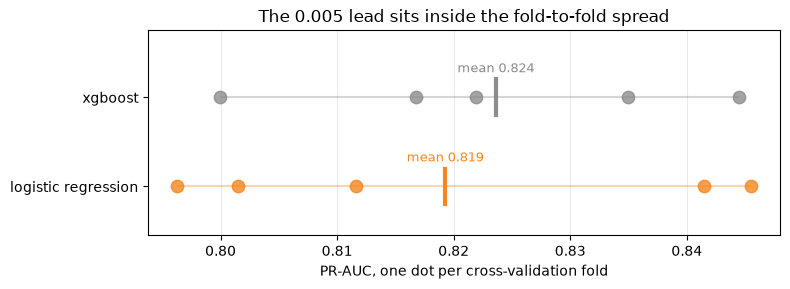

In [3]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Is XGBoost actually better, or did it just land on top this time?
folds = {}
for name in ["logistic regression", "xgboost"]:
    folds[name] = cross_val_score(clone(fitted[name]), Xtr, ytr, cv=cv, scoring="average_precision")
    f = folds[name]
    print(f"{name:22} mean {f.mean():.3f}   std {f.std():.3f}   {np.round(f, 3)}")

# The table above states that the lead is inside the noise. The chart shows it, which
# is harder to argue with. Each dot is one fold. The bar is the mean.
fig, ax = plt.subplots(figsize=(8, 3))
colors = {"logistic regression": "#F6861F", "xgboost": "#8C8C8C"}
for i, (name, f) in enumerate(folds.items()):
    ax.hlines(i, f.min(), f.max(), color=colors[name], lw=1.5, alpha=0.35, zorder=2)
    ax.scatter(f, [i] * len(f), s=80, alpha=0.8, color=colors[name], zorder=3)
    ax.plot([f.mean()] * 2, [i - 0.2, i + 0.2], color=colors[name], lw=3, zorder=4)
    ax.annotate(f"mean {f.mean():.3f}", (f.mean(), i + 0.28), ha="center", fontsize=9,
                color=colors[name])
ax.set_yticks(range(len(folds)))
ax.set_yticklabels(list(folds))
ax.set_ylim(-0.55, len(folds) - 0.25)
ax.set_xlabel("PR-AUC, one dot per cross-validation fold")
ax.set_title("The 0.005 lead sits inside the fold-to-fold spread")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "model_fold_noise.png", dpi=110)
plt.show()

## The Model I Choose

The gap between them is 0.005. The folds swing by 0.020.

So the lead is inside the noise. Rerun this with a different seed and the order could flip. XGBoost is not better than logistic regression on this data. It is tied with it, and it happened to land on top.

That settles it. **Logistic regression.**

Not because it scores highest, because it does not. Because when two models are tied, the tiebreak should be something that actually matters, and here that is whether a student can be told why they were flagged. A logistic coefficient is a number a tutor can read out loud. A boosted ensemble of 300 trees is not.

The first version of this notebook also picked logistic regression, and picked it for the wrong reason. It said the model caught the most dropouts, best recall in the table, so that must be the one to ship.

Two things are wrong with that, and the second one is the real one.

Look at the recall column now. Logistic regression sits at **0.750**, and `logistic regression + PCA` beats it at **0.757**. The old argument does not survive its own criterion any more.

But the deeper problem is that **the recall column is not a fact about the models at all.** Every number in it was measured at a probability cutoff of 0.5, and nobody chose 0.5. Rank the models by that column and you are ranking them by a library default. The next section is about why that number was never real.

## 3. The Threshold Nobody Chose

Every recall figure above sits at a probability cutoff of 0.5.

Nobody picked 0.5. It is the default, and it means the model flags whichever students happen to land above the halfway line. On this data that turns out to be 44 percent of the cohort. That number came from the shape of the fitted probabilities. It did not come from any decision about how many students the school can actually reach.

Which makes recall at 0.5 a fact about the default, not a fact about the model.

One thing to be precise about before going further, because this section is about to say "probability" a great many times. `class_weight="balanced"` shifts the intercept to make the rarer class easier to reach, and in doing so it **decalibrates** the outputs. So 0.445 is not a claim that a student has a 44.5 percent chance of dropping out. It is a position in a ranking.

That is fine, and it is worth explaining why rather than waving at it. Nothing downstream needs the number to be a true probability. The capacity rule below picks a **quantile** of the out-of-fold scores, which only needs the ranking to be right. The expected-value table counts **realized outcomes** at each cutoff rather than trusting the scores to be probabilities. And Step 5 commits to never showing the score to a student at all. A calibrated probability would be a nicer object to hold, but nothing here would do anything different with one.

These are ranking scores. Only the ranking is ever used.

Step 1 wrote down a business case with real numbers in it. A retained student is worth 2,100 EUR. Reaching one costs somewhere between 50 and 300 EUR. Then that case was never mentioned again. The cutoff is exactly where it belongs, because the cutoff is the only place in this whole project where cost and benefit actually meet.

The cutoff gets chosen on out-of-fold predictions inside the training set, then applied once to test. Choosing it on test would be tuning on the test set with extra steps.

In [4]:
from sklearn.model_selection import cross_val_predict

model = fitted["logistic regression"]

# Out-of-fold predictions on TRAIN. Every student gets scored by a model that never
# saw them, which is the closest honest stand-in for unseen data.
oof = cross_val_predict(clone(model), Xtr, ytr, cv=cv, method="predict_proba")[:, 1]
proba = model.predict_proba(Xte)[:, 1]

def at(threshold):
    pred = (proba >= threshold).astype(int)
    return {"threshold": round(threshold, 2),
            "recall": round(recall_score(yte, pred), 3),
            "precision": round(precision_score(yte, pred), 3),
            "flagged": f"{pred.mean():.1%}"}

# A capacity of 45 percent means the tutoring team can reach 45 percent of the cohort.
# The threshold that produces that flag rate on the out-of-fold scores is the cutoff.
capacity = {f"capacity {int(c * 100)}%": float(np.quantile(oof, 1 - c)) for c in [0.50, 0.45, 0.40, 0.35, 0.30]}
pd.DataFrame([at(0.50)] + [at(t) for t in capacity.values()],
             index=["default 0.5"] + list(capacity))

,threshold,recall,precision,flagged
default 0.5,0.50,0.750,0.670,43.8%
capacity 50%,0.38,0.838,0.609,53.9%
capacity 45%,0.45,0.796,0.644,48.3%
capacity 40%,0.50,0.750,0.670,43.8%
capacity 35%,0.57,0.697,0.723,37.7%
capacity 30%,0.64,0.630,0.768,32.1%


The default sits at capacity 40 percent. That is all it ever was. A staffing decision, made by accident, by a library default.

Move it to 45 percent and recall climbs to **0.796**. Same model, same data, better number, and now the number answers a question somebody actually asked. How many students can the tutoring team reach, and how many leavers does that catch?

But capacity is a guess. The Step 1 numbers are not, so they get a say.

expected value per 1,000 students, best case against deployed at cutoff 0.445
   50 EUR:  best  199,022   deployed  171,942   gap  27,080
  150 EUR:  best  125,289   deployed  123,595   gap   1,694
  300 EUR:  best   58,967   deployed   51,074   gap   7,893


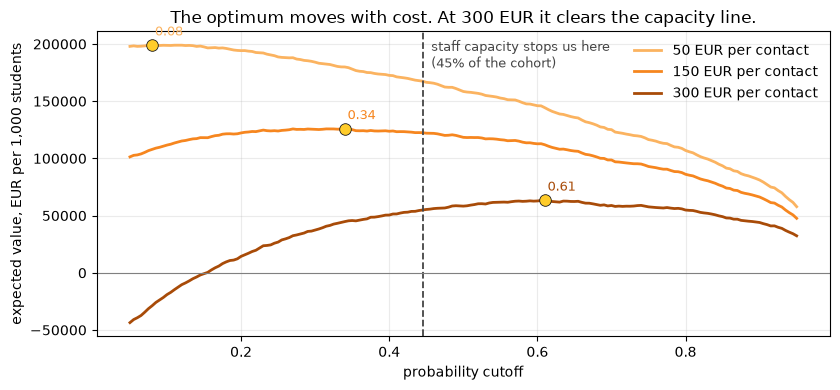

,outreach cost,best threshold,flagged,recall,"value per 1,000 students"
0,50 EUR,0.08,93.1%,0.996,"199,022 EUR"
1,150 EUR,0.34,59.4%,0.870,"125,289 EUR"
2,300 EUR,0.61,34.4%,0.658,"58,967 EUR"


In [5]:
VALUE, UPLIFT = 2100, 0.30   # euros kept per retained student, share of outreach that works

def expected_value(threshold, probs, truth, cost):
    flagged = probs >= threshold
    caught = (flagged & (truth == 1)).sum()
    return (caught * VALUE * UPLIFT - flagged.sum() * cost) / len(truth) * 1000

grid = np.linspace(0.05, 0.95, 181)
rows = []
for cost in [50, 150, 300]:
    # The best cutoff is found on the out-of-fold TRAIN scores, then applied to test.
    best = max(grid, key=lambda t: expected_value(t, oof, ytr.values, cost))
    rows.append({
        "outreach cost": f"{cost} EUR",
        "best threshold": round(best, 2),
        "flagged": f"{(proba >= best).mean():.1%}",
        "recall": round(recall_score(yte, (proba >= best).astype(int)), 3),
        "value per 1,000 students": f"{expected_value(best, proba, yte.values, cost):,.0f} EUR",
    })

# The table above is each cost's profit-optimal cutoff. The tool does not deploy there.
# It deploys at the capacity-45% operating point, 0.445, which flags fewer students, so
# the value it actually realizes is lower. Printing both lets the report and the decks
# quote the deployed number and not only the best case, and it puts the cost of the
# staffing constraint on the page as a number rather than a hand-wave.
op_thr = capacity["capacity 45%"]
print(f"expected value per 1,000 students, best case against deployed at cutoff {op_thr:.3f}")
for cost in [50, 150, 300]:
    best = max(grid, key=lambda t: expected_value(t, oof, ytr.values, cost))
    ev_best = expected_value(best, proba, yte.values, cost)
    ev_dep = expected_value(op_thr, proba, yte.values, cost)
    print(f"  {cost:3} EUR:  best {ev_best:>8,.0f}   deployed {ev_dep:>8,.0f}   gap {ev_best - ev_dep:>7,.0f}")

# The chart is the argument. Each curve peaks well to the LEFT of where staff capacity
# lets us operate, which is the whole tension in this project, and a table hides it.
thr45 = capacity["capacity 45%"]
fig, ax = plt.subplots(figsize=(8.5, 4))
for cost, color in zip([50, 150, 300], ["#FBB360", "#F6861F", "#A84B08"]):
    ev = [expected_value(t, oof, ytr.values, cost) for t in grid]
    ax.plot(grid, ev, lw=2, color=color, label=f"{cost} EUR per contact")
    peak = grid[int(np.argmax(ev))]
    ax.scatter([peak], [max(ev)], s=70, color="#FFCC2A", edgecolor="#1A1A1A", linewidth=0.6, zorder=5)
    ax.annotate(f"{peak:.2f}", (peak, max(ev)), textcoords="offset points",
                xytext=(2, 7), fontsize=9, color=color)

ax.axvline(thr45, ls="--", color="#444", lw=1.3)
ax.annotate("staff capacity stops us here\n(45% of the cohort)", (thr45, ax.get_ylim()[1]),
            textcoords="offset points", xytext=(6, -26), fontsize=9, color="#444")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("probability cutoff")
ax.set_ylabel("expected value, EUR per 1,000 students")
ax.set_title("The optimum moves with cost. At 300 EUR it clears the capacity line.")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "expected_value.png", dpi=110)
plt.show()

pd.DataFrame(rows)

The economics say flag broadly. A saved student returns 630 EUR in expectation, against 150 EUR to reach one, so at the middle cost the model wants to contact 59 percent of the cohort and catch 87 percent of the leavers.

That is a strange thing for a targeting tool to say, and it is worth sitting with rather than hiding. When a save is worth four times what a contact costs, being wrong about a student is cheap and missing one is not. Under those numbers there is barely any triage left to do.

The chart is worth reading rather than skipping, because it caught me being sloppy. I had written that staff time runs out long before the economics do. Look at the 300 EUR curve. **It peaks at 0.61, which is tighter than the capacity line.** At that cost, contacting a student is expensive enough that the economics want *fewer* flags than the tutoring team could actually handle, and capacity is not the binding constraint at all.

So the honest version has a condition on it. Staff capacity binds at 50 and 150 EUR per contact. At 300 EUR the money binds first. Whether the school is capacity-limited or cost-limited depends on a number I do not have, and a table of three rows let me write past that. The curve does not.

What survives either way. **The ranked list is the product. The binary flag is not.** Step 1 framed it that way and the economics have now confirmed it. A tutor working down a list from most at risk to least does not need a cutoff at all, and does not care which constraint binds.

A cutoff is still needed, to audit fairness in Step 5 and to report a single honest number. So it goes at **capacity 45 percent**, which assumes the school is capacity-limited, the case at the low and middle outreach costs. The cost of that choice is printed above and it is small. At the deployed cutoff the value comes to **171,942, 123,595, and 51,074 EUR per 1,000 students** at 50, 150, and 300 EUR a contact. At the middle cost that is 1,694 below the value-optimal 125,289. Fitting the tool to a target the school can actually staff is very nearly free.

operating threshold 0.445

                      not flagged  flagged
actually graduated            317      125
actually dropped out           58      226


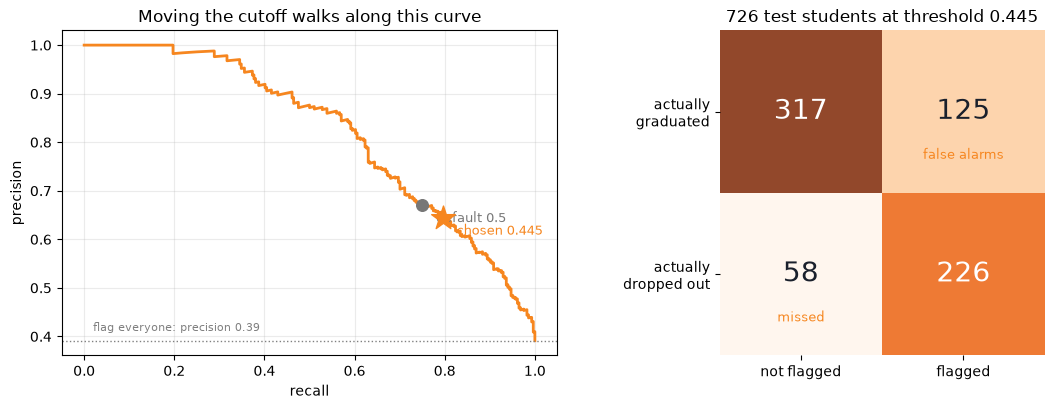

In [6]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve

THRESHOLD = float(np.quantile(oof, 0.55))   # flags the top 45 percent
pred = (proba >= THRESHOLD).astype(int)

print(f"operating threshold {THRESHOLD:.3f}\n")
tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
print(pd.DataFrame([[tn, fp], [fn, tp]],
                   index=["actually graduated", "actually dropped out"],
                   columns=["not flagged", "flagged"]))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Left. The whole curve, with the two cutoffs marked. The default is not a decision,
# it is a place the library happened to leave us.
prec, rec, _ = precision_recall_curve(yte, proba)
ax[0].plot(rec, prec, lw=2, color="#F6861F")
base = float((yte == 1).mean())
ax[0].axhline(base, ls=":", color="grey", lw=1)
ax[0].annotate(f"flag everyone: precision {base:.2f}", (0.02, base + 0.02),
               fontsize=8, color="grey")
for label, t, marker, size, colour in [
    ("default 0.5", 0.5, "o", 70, "#777"),
    (f"chosen {THRESHOLD:.3f}", THRESHOLD, "*", 320, "#F6861F"),
]:
    p = (proba >= t).astype(int)
    r_, p_ = recall_score(yte, p), precision_score(yte, p)
    ax[0].scatter([r_], [p_], s=size, marker=marker, color=colour, zorder=5)
    ax[0].annotate(label, (r_, p_), textcoords="offset points", xytext=(10, -12),
                   fontsize=9, color=colour)
ax[0].set_xlabel("recall")
ax[0].set_ylabel("precision")
ax[0].set_title("Moving the cutoff walks along this curve")
ax[0].grid(alpha=0.25)

# Right. Who that actually is, in students. The 125 is the number worth staring at.
cm = np.array([[tn, fp], [fn, tp]])
ax[1].imshow(cm, cmap="Oranges", alpha=0.85)
for (i, j), v in np.ndenumerate(cm):
    ax[1].text(j, i, f"{v}", ha="center", va="center", fontsize=20,
               color="white" if v > cm.max() * 0.55 else "#1a202c")
ax[1].set_xticks([0, 1], ["not flagged", "flagged"])
ax[1].set_yticks([0, 1], ["actually\ngraduated", "actually\ndropped out"])
ax[1].set_title(f"726 test students at threshold {THRESHOLD:.3f}")
ax[1].annotate("missed", (0, 1), textcoords="offset points", xytext=(0, -34),
               ha="center", fontsize=9, color="#F6861F")
ax[1].annotate("false alarms", (1, 0), textcoords="offset points", xytext=(0, -34),
               ha="center", fontsize=9, color="#F6861F")
for s in ax[1].spines.values():
    s.set_visible(False)

fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "operating_point.png", dpi=110)
plt.show()

226 leavers caught. 58 missed. And 125 graduates contacted who were never going to leave.

Those 125 are the real cost of this tool, and they are not free. A student pulled into a retention conversation they did not need has been told, in effect, that a system thinks they are failing.

Step 5 asks who those 125 are. The answer is not evenly spread.

In [7]:
import json

chosen = "logistic regression"
joblib.dump(fitted[chosen], ROOT / "models" / "model.joblib")
with open(ROOT / "models" / "metrics.json", "w") as f:
    json.dump({
        "chosen": chosen,
        "operating_threshold": round(THRESHOLD, 3),
        "threshold_rule": "quantile of out-of-fold training scores matching 45 percent staff capacity",
        "results": results,   # carries best params, so every row here can be rebuilt
    }, f, indent=2)
print("saved model.joblib (", chosen, f") at threshold {THRESHOLD:.3f}, and metrics.json")

saved model.joblib ( logistic regression ) at threshold 0.445, and metrics.json


## What Step 4 Settles

1. Seven models were trained and tuned on the enrollment-time features, using cross-validation on the training set. PCA rode along as one of them, and lost honestly.
2. XGBoost led by 0.005 against a fold-to-fold swing of 0.020, so the lead is noise. The top four models are tied.
3. The neural net lost to the simpler models, which answers the deep learning question for this data.
4. Logistic regression is the choice, and not because it scores highest. When models are tied, the tiebreak is whether a student can be told why they were flagged.
5. The cutoff was chosen, rather than inherited. It sits at 0.445, from out-of-fold training scores at 45 percent staff capacity, giving recall 0.796. The recall figures in the model table are not facts about the models. They are facts about the 0.5 default nobody picked.
6. The Step 1 business case finally did some work. It says the ranked list is the product and the binary flag is not.
7. Plotting the expected-value curve corrected me on which constraint actually binds. Staff capacity binds at 50 and 150 EUR per contact. At 300 EUR the money binds first, and the optimum is *tighter* than what the team could staff. The cost of running at capacity rather than the optimum is small, 123,595 EUR per 1,000 at the middle contact cost against the optimum's 125,289. Three rows of a table let me write past all of that. The curve did not.
8. The chosen model, the threshold, and every model's best hyperparameters are saved to models.

Step 5 takes this model, explains its decisions, checks it for bias across the four sensitive attributes at this threshold, and tries to reduce any unfairness it finds.